# ExoHabX - AI Astrobiologist
## Predicting Exoplanet Habitability Without Complete Data
> "What if we could score a planet's potential for life, even when science hasn't measured everything yet?"

**Author:** Walid Idbennacer | AstroWalid  
**Dataset:** NASA Exoplanet Archive × Habitable Worlds Catalog  
**Model:** Random Forest Regressor with custom sample weighting  
**Result:** R² = 0.8767 | MAE = 0.0234

## 1. Libraries & Dependencies
All scientific computing, visualization, and ML libraries used in this project.

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import xgboost as xgb
from sklearn.preprocessing import StandardScaler
from sklearn.impute import KNNImputer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score, classification_report, confusion_matrix, accuracy_score


c:\Users\user\Documents\Data Projects\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 2. Loading the Datasets
We work with two independent sources:
- **NASA Exoplanet Archive** with 6291 planets, 84 columns, no ESI column
- **Habitable Worlds Catalog (HWC)** with 5599 planets, 118 columns, includes ESI

The core problem: NASA has more planets and better orbital data. HWC has the ESI score we want to predict. Neither dataset alone is enough.

In [2]:
df_hwc = pd.read_csv('../datasets/exoplanet_hwc.csv')
df_hwc.head()

,P_NAME,P_DETECTION,P_DISCOVERY_FACILITY,P_YEAR,P_UPDATE,P_MASS,P_MASS_ERROR_MIN,P_MASS_ERROR_MAX,P_MASS_LIMIT,P_MASS_ORIGIN,...,S_ABIO_ZONE,S_TIDAL_LOCK,P_HABZONE_OPT,P_HABZONE_CON,P_TYPE_TEMP,P_HABITABLE,P_ESI,S_CONSTELLATION,S_CONSTELLATION_ABR,S_CONSTELLATION_ENG
0,OGLE-2016-BLG-1227L b,Microlensing,OGLE,2020,2020-04-02,250.00,-120.0,413.0,0,Mass,...,NaN,0.214133,0,0,NaN,0,NaN,Scorpius,Sco,Scorpion
1,Kepler-276 c,Transit,Kepler,2013,2018-09-25,16.60,-3.6,4.4,0,Mass,...,2.097783,0.316980,0,0,Hot,0,0.272032,Cygnus,Cyg,Swan
2,Kepler-829 b,Transit,Kepler,2016,2019-04-16,5.10,NaN,NaN,0,M-R relationship,...,1.756317,0.459559,0,0,Hot,0,0.254763,Lyra,Lyr,Lyre
3,K2-283 b,Transit,K2,2018,2019-09-05,12.20,NaN,NaN,0,M-R relationship,...,0.568374,0.443760,0,0,Hot,0,0.193906,Pisces,Psc,Fishes
4,Kepler-477 b,Transit,Kepler,2016,2019-04-16,4.94,NaN,NaN,0,M-R relationship,...,0.768502,0.386150,0,0,Hot,0,0.276721,Lyra,Lyr,Lyre


In [3]:
df_nasa = pd.read_csv('../datasets/exoplanet_nasa.csv', comment='#')
df_nasa.head()

,pl_name,hostname,sy_snum,sy_pnum,discoverymethod,disc_year,disc_facility,pl_controv_flag,pl_orbper,pl_orbpererr1,...,sy_disterr2,sy_vmag,sy_vmagerr1,sy_vmagerr2,sy_kmag,sy_kmagerr1,sy_kmagerr2,sy_gaiamag,sy_gaiamagerr1,sy_gaiamagerr2
0,11 Com b,11 Com,2,1,Radial Velocity,2007.0,Xinglong Station,0,323.21000,0.06,...,-1.9238,4.72307,0.023,-0.023,2.282,0.346,-0.346,4.44038,0.003848,-0.003848
1,11 UMi b,11 UMi,1,1,Radial Velocity,2009.0,Thueringer Landessternwarte Tautenburg,0,516.21997,3.20,...,-1.9765,5.01300,0.005,-0.005,1.939,0.270,-0.270,4.56216,0.003903,-0.003903
2,14 And b,14 And,1,1,Radial Velocity,2008.0,Okayama Astrophysical Observatory,0,186.76000,0.11,...,-0.7140,5.23133,0.023,-0.023,2.331,0.240,-0.240,4.91781,0.002826,-0.002826
3,14 Her b,14 Her,1,2,Radial Velocity,2002.0,W. M. Keck Observatory,0,1766.41000,0.67,...,-0.0073,6.61935,0.023,-0.023,4.714,0.016,-0.016,6.38300,0.000351,-0.000351
4,16 Cyg B b,16 Cyg B,3,1,Radial Velocity,1996.0,Multiple Observatories,0,798.50000,1.00,...,-0.0111,6.21500,0.016,-0.016,4.651,0.016,-0.016,6.06428,0.000603,-0.000603


In [4]:
print(df_nasa.shape)
print(df_nasa.columns)
print(df_nasa.dtypes)
print(df_nasa.describe())

(6291, 84)
Index(['pl_name', 'hostname', 'sy_snum', 'sy_pnum', 'discoverymethod',
       'disc_year', 'disc_facility', 'pl_controv_flag', 'pl_orbper',
       'pl_orbpererr1', 'pl_orbpererr2', 'pl_orbperlim', 'pl_orbsmax',
       'pl_orbsmaxerr1', 'pl_orbsmaxerr2', 'pl_orbsmaxlim', 'pl_rade',
       'pl_radeerr1', 'pl_radeerr2', 'pl_radelim', 'pl_radj', 'pl_radjerr1',
       'pl_radjerr2', 'pl_radjlim', 'pl_bmasse', 'pl_bmasseerr1',
       'pl_bmasseerr2', 'pl_bmasselim', 'pl_bmassj', 'pl_bmassjerr1',
       'pl_bmassjerr2', 'pl_bmassjlim', 'pl_bmassprov', 'pl_orbeccen',
       'pl_orbeccenerr1', 'pl_orbeccenerr2', 'pl_orbeccenlim', 'pl_insol',
       'pl_insolerr1', 'pl_insolerr2', 'pl_insollim', 'pl_eqt', 'pl_eqterr1',
       'pl_eqterr2', 'pl_eqtlim', 'ttv_flag', 'st_spectype', 'st_teff',
       'st_tefferr1', 'st_tefferr2', 'st_tefflim', 'st_rad', 'st_raderr1',
       'st_raderr2', 'st_radlim', 'st_mass', 'st_masserr1', 'st_masserr2',
       'st_masslim', 'st_met', 'st_meterr1', 'st

In [5]:
print(df_hwc.shape)
print(df_hwc.columns)
print(df_hwc.dtypes)
print(df_hwc.describe())

(5599, 118)
Index(['P_NAME', 'P_DETECTION', 'P_DISCOVERY_FACILITY', 'P_YEAR', 'P_UPDATE',
       'P_MASS', 'P_MASS_ERROR_MIN', 'P_MASS_ERROR_MAX', 'P_MASS_LIMIT',
       'P_MASS_ORIGIN',
       ...
       'S_ABIO_ZONE', 'S_TIDAL_LOCK', 'P_HABZONE_OPT', 'P_HABZONE_CON',
       'P_TYPE_TEMP', 'P_HABITABLE', 'P_ESI', 'S_CONSTELLATION',
       'S_CONSTELLATION_ABR', 'S_CONSTELLATION_ENG'],
      dtype='str', length=118)
P_NAME                      str
P_DETECTION                 str
P_DISCOVERY_FACILITY        str
P_YEAR                    int64
P_UPDATE                    str
                         ...   
P_HABITABLE               int64
P_ESI                   float64
S_CONSTELLATION             str
S_CONSTELLATION_ABR         str
S_CONSTELLATION_ENG         str
Length: 118, dtype: object
            P_YEAR        P_MASS  P_MASS_ERROR_MIN  P_MASS_ERROR_MAX  \
count  5599.000000   5592.000000       2506.000000       2506.000000   
mean   2016.188962    442.521283       -127.777520       

## 3. Dataset Merging Strategy
We perform an inner join on planet name (`pl_name` = `P_NAME`).
This gives us 5566 planets that exist in both datasets by combining NASA's orbital precision with HWC's habitability scores.

**Why inner join?** We only keep planets where we can verify the ESI ground truth. No ESI = no training signal.

In [6]:
master_df = pd.merge(df_nasa, df_hwc, left_on='pl_name', right_on='P_NAME', how='inner')

features = ['pl_rade', 'pl_bmasse', 'pl_eqt', 'pl_orbsmax', 'pl_orbeccen', 'st_teff', 'sy_snum']
target = 'P_ESI'

final_df = master_df[['pl_name'] + features + [target]].copy()
final_df.shape

(5566, 9)

## 4. Handling Missing Data
Rather than dropping rows with missing values (which would lose valuable rare Earth-like planets), we use KNN Imputation by estimating missing values from the 5 most similar planets in feature space.

**Pipeline:**
1. StandardScaler → normalize features
2. KNNImputer (k=5) → fill missing values
3. Inverse transform → restore original scale

In [7]:
final_df.isnull().sum()

pl_name           0
pl_rade          46
pl_bmasse        30
pl_eqt         1409
pl_orbsmax      257
pl_orbeccen     720
st_teff         218
sy_snum           0
P_ESI           240
dtype: int64

In [8]:
final_df = final_df.dropna(subset=[target]).reset_index(drop=True)
final_df.shape

(5326, 9)

In [9]:
X_features = final_df[features]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_features)

In [10]:
imputer = KNNImputer(n_neighbors=5)
X_imputed_scaled = imputer.fit_transform(X_scaled)
X_imputed = scaler.inverse_transform(X_imputed_scaled)
final_df[features] = X_imputed

In [11]:
print(final_df.isnull().sum())
print(final_df.head(3))

pl_name        0
pl_rade        0
pl_bmasse      0
pl_eqt         0
pl_orbsmax     0
pl_orbeccen    0
st_teff        0
sy_snum        0
P_ESI          0
dtype: int64
    pl_name  pl_rade    pl_bmasse    pl_eqt  pl_orbsmax  pl_orbeccen  st_teff  \
0  11 Com b     12.2  4914.898486  1437.380       1.178        0.238   4874.0   
1  11 UMi b     12.3  4684.814200   607.766       1.530        0.080   4213.0   
2  14 And b     13.1  1131.151301   909.766       0.775        0.000   4888.0   

   sy_snum     P_ESI  
0      2.0  0.087644  
1      1.0  0.081366  
2      1.0  0.077422  


## 5. Exploratory Data Analysis
Four key visualizations to understand our data before modeling:
- ESI score distribution across all planets
- Feature correlation heatmap
- Mass vs Radius relationship (log scale)
- Orbital distance vs Equilibrium temperature

In [12]:
sns.set_theme(style="darkgrid")
plt.rcParams['figure.figsize'] = (25, 15)

Text(0, 0.5, 'Number of Planets')

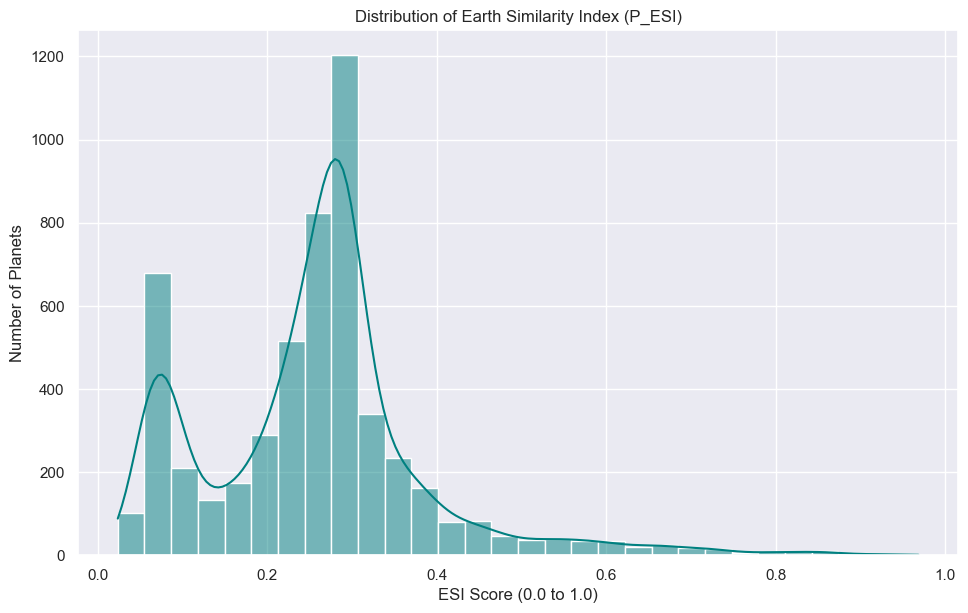

In [13]:
# 1. Distribution of the Target (P_ESI)
plt.subplot(2, 2, 1)
sns.histplot(final_df['P_ESI'], bins=30, kde=True, color='teal')
plt.title('Distribution of Earth Similarity Index (P_ESI)')
plt.xlabel('ESI Score (0.0 to 1.0)')
plt.ylabel('Number of Planets')

Text(0.5, 1.0, 'Feature Correlation Heatmap')

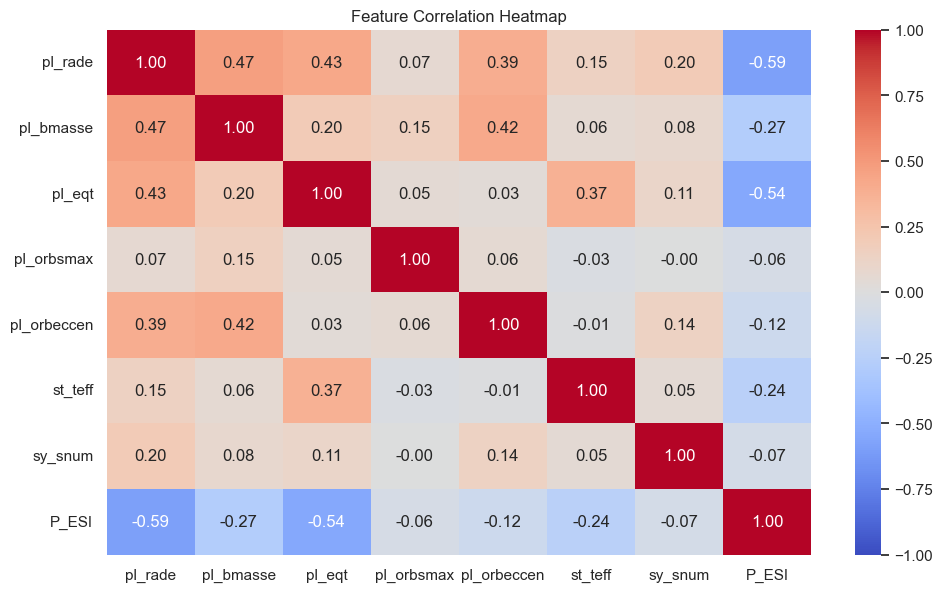

In [14]:
# 2. The Correlation Heatmap
plt.subplot(2, 2, 2)
corr_matrix = final_df[features + [target]].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)
plt.title('Feature Correlation Heatmap')

Text(0, 0.5, 'Planet Radius (Earth Radii)')

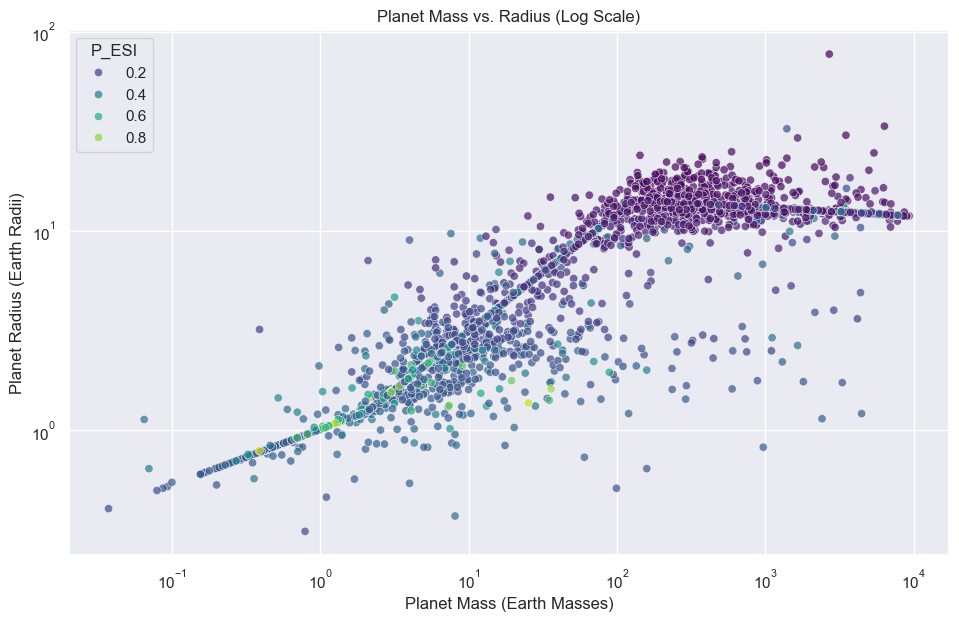

In [15]:
# 3. Physics: Mass vs. Radius (Colored by ESI)
plt.subplot(2, 2, 3)
# Using log scale because some gas giants are massively heavy
sns.scatterplot(
    data=final_df, 
    x='pl_bmasse', 
    y='pl_rade', 
    hue='P_ESI', 
    palette='viridis', 
    alpha=0.7
)
plt.xscale('log')
plt.yscale('log')
plt.title('Planet Mass vs. Radius (Log Scale)')
plt.xlabel('Planet Mass (Earth Masses)')
plt.ylabel('Planet Radius (Earth Radii)')

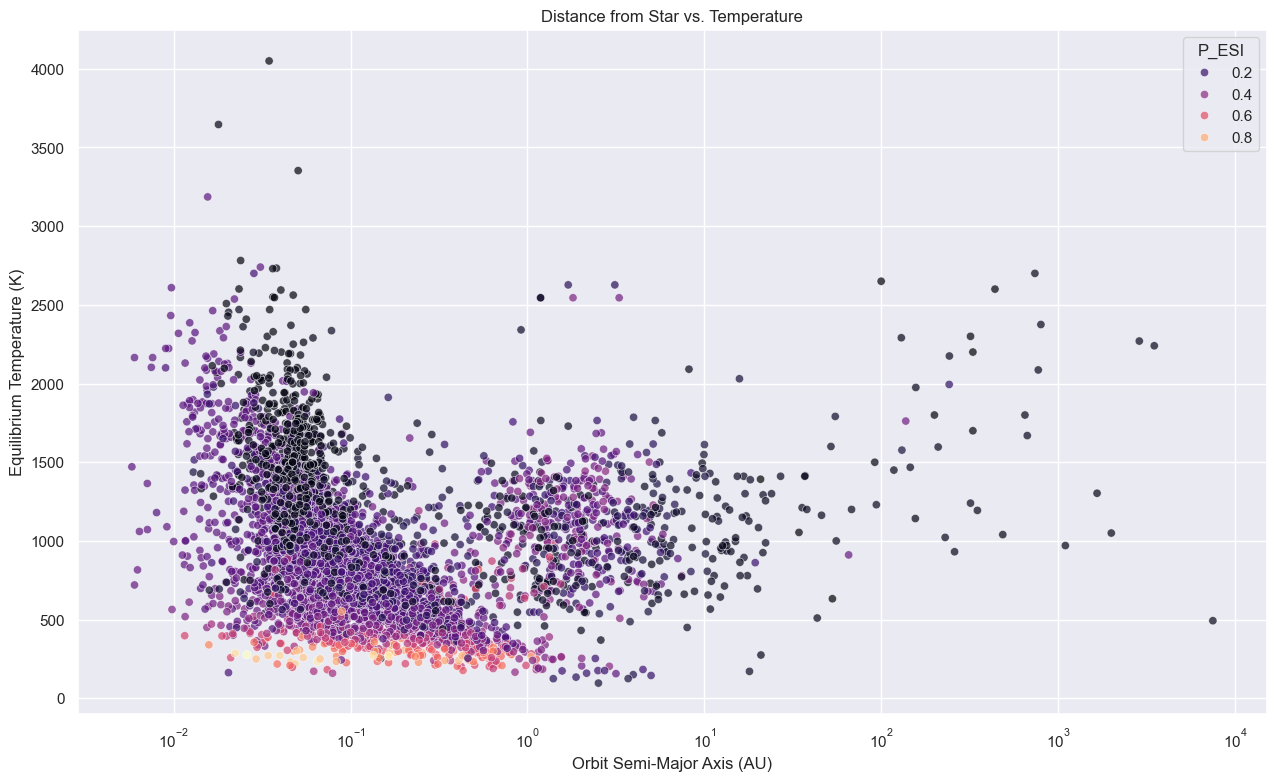

In [16]:
# 4. Habitability: Distance vs. Temperature
plt.subplot(2, 2, 4)
sns.scatterplot(
    data=final_df, 
    x='pl_orbsmax', 
    y='pl_eqt', 
    hue='P_ESI', 
    palette='magma', 
    alpha=0.7
)
plt.xscale('log')
plt.title('Distance from Star vs. Temperature')
plt.xlabel('Orbit Semi-Major Axis (AU)')
plt.ylabel('Equilibrium Temperature (K)')

plt.tight_layout()
plt.show()

## 6. Model Training: Random Forest with Sample Weighting + Evaluation
**The class imbalance problem:** Out of 5326 planets, fewer than 2% have ESI > 0.5. A naive model would just predict everything as non-habitable and still get 98% accuracy is useless for our goal.

**Our solution is custom sample weights:**
- ESI > 0.5 → weight × 5
- ESI > 0.8 → weight × 20

This forces the model to pay 20x more attention to the rarest, most Earth-like planets during training.

In [17]:
X = final_df[['pl_rade', 'pl_bmasse', 'pl_eqt', 'pl_orbsmax', 'pl_orbeccen', 'st_teff', 'sy_snum']]
y = final_df['P_ESI']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [18]:
rf_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)

sample_weights = np.ones(len(y_train))

sample_weights[y_train > 0.5] = 5   # Make planets with ESI > 0.5 five times more important
sample_weights[y_train > 0.8] = 20  # Make the rarest Earths TWENTY times more important

rf_model.fit(X_train, y_train, sample_weight=sample_weights)

y_pred = rf_model.predict(X_test)


mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
cr = classification_report(y_test > 0.5, y_pred > 0.5, target_names=['Non-Habitable (ESI ≤ 0.5)', 'Potentially Habitable (ESI > 0.5)'])

print(f"--- Model Performance ---")
print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"R-squared Score (R2):      {r2:.4f}")
print(f"Classification Report:\n{cr}")
print(f"Confusion Matrix:\n{confusion_matrix(y_test > 0.5, y_pred > 0.5)}")


print("\n--- Example Prediction ---")
print(f"Actual ESI:    {y_test.iloc[50]:.4f}")
print(f"Predicted ESI: {y_pred[50]:.4f}")

--- Model Performance ---
Mean Absolute Error (MAE): 0.0234
R-squared Score (R2):      0.8767
Classification Report:
                                   precision    recall  f1-score   support

        Non-Habitable (ESI ≤ 0.5)       0.99      0.99      0.99      1020
Potentially Habitable (ESI > 0.5)       0.75      0.85      0.80        46

                         accuracy                           0.98      1066
                        macro avg       0.87      0.92      0.89      1066
                     weighted avg       0.98      0.98      0.98      1066

Confusion Matrix:
[[1007   13]
 [   7   39]]

--- Example Prediction ---
Actual ESI:    0.2694
Predicted ESI: 0.2752


## 7. XGBoost Model + Evaluation comparision with Random Forest model
We test an XGBoost regressor with the same sample weighting strategy and compare it directly against the Random Forest model.

This lets us evaluate whether gradient boosting provides a stronger signal for the rare, high-ESI planets.

In [22]:
xgb_model = xgb.XGBRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1,
    objective='reg:squarederror',
    verbosity=0
)

xgb_model.fit(X_train, y_train, sample_weight=sample_weights)

y_pred_xgb = xgb_model.predict(X_test)

mae_xgb = mean_absolute_error(y_test, y_pred_xgb)
r2_xgb = r2_score(y_test, y_pred_xgb)
accuracy_xgb = accuracy_score(y_test > 0.5, y_pred_xgb > 0.5)

print('--- XGBoost Model Performance ---')
print(f'Mean Absolute Error (MAE): {mae_xgb:.4f}')
print(f'R-squared Score (R2):      {r2_xgb:.4f}')
print(f'Classification Accuracy:   {accuracy_xgb:.4f}')
print('Confusion Matrix:')
print(confusion_matrix(y_test > 0.5, y_pred_xgb > 0.5))

comparison_df = pd.DataFrame({
    'Model': ['Random Forest', 'XGBoost'],
    'MAE': [mae, mae_xgb],
    'R2': [r2, r2_xgb],
    'Classification Accuracy': [accuracy_score(y_test > 0.5, y_pred > 0.5), accuracy_xgb]
})

print('\n--- Model Comparison ---')
print(comparison_df.to_string(index=False))

--- XGBoost Model Performance ---
Mean Absolute Error (MAE): 0.0240
R-squared Score (R2):      0.8795
Classification Accuracy:   0.9794
Confusion Matrix:
[[1005   15]
 [   7   39]]

--- Model Comparison ---
        Model      MAE       R2  Classification Accuracy
Random Forest 0.023365 0.876676                 0.981238
      XGBoost 0.023955 0.879478                 0.979362


### Comparison Summary
XGBoost delivered a slightly higher R² but a marginally worse MAE and lower binary classification accuracy than the Random Forest baseline. This means Random Forest remains the best choice for minimizing prediction error here, while XGBoost is a strong validation check for model stability.

## 8. What Makes a Planet Habitable?
Feature importance reveals which physical parameters the model relies on most when scoring habitability.

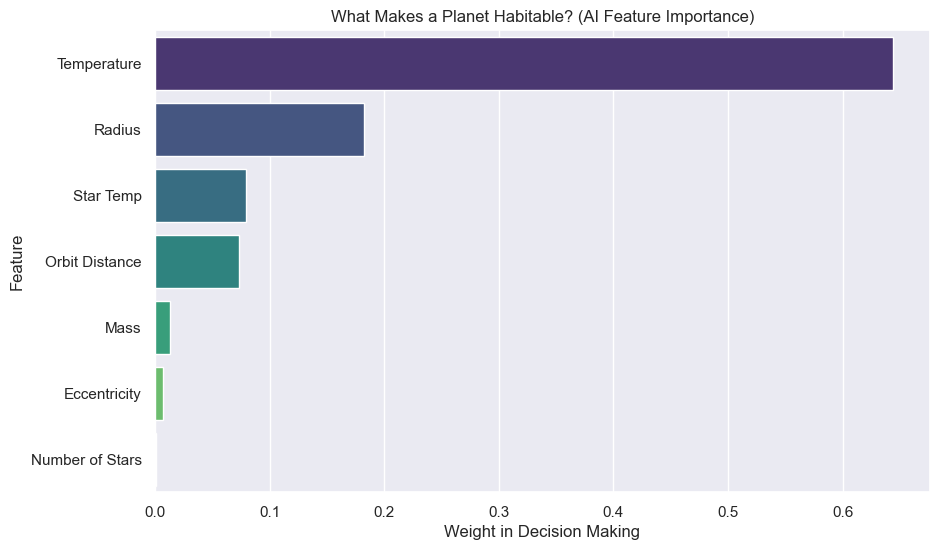

In [ ]:
importances = rf_model.feature_importances_

feature_names = ['Radius', 'Mass', 'Temperature', 'Orbit Distance', 'Eccentricity', 'Star Temp', 'Number of Stars']
importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
importance_df = importance_df.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=importance_df, x='Importance', y='Feature', palette='viridis')    
plt.title("What Makes a Planet Habitable? (AI Feature Importance)")
plt.xlabel("Weight in Decision Making")
plt.show()

## 9. Exporting the Model
The trained model and scaler are exported via joblib for integration into the ExoHabX web application, enabling real-time habitability prediction directly in the browser interface.

In [20]:
import joblib

joblib.dump(rf_model, 'ai_astrobiologist_model.pkl')

joblib.dump(scaler, 'data_scaler.pkl')

print("Model and Scaler successfully exported!")

Model and Scaler successfully exported!


## 10. Summary & Next Steps

| Metric | Value |
|--------|-------|
| MAE | 0.0234 |
| R² Score | 0.8767 |
| Habitable Classification Accuracy | 98% |

**What this means:** Our model can predict a planet's ESI score within ±0.023 of the true value, using only 7 commonly available parameters without needing the full ESI formula inputs.


> *Built by Walid Idbennacer (Astrowalid)* 🌌